# AgentMod Training and Evaluation

This notebook runs the full AgentMod pipeline end-to-end using from-scratch NumPy ML implementations.

In [1]:
# Setup — imports, set random seeds (numpy seed=42)
import os
import sys
import pickle
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

ROOT = os.path.abspath(os.path.join(os.getcwd(), "..")) if os.path.basename(os.getcwd()) == "notebooks" else os.path.abspath(".")
SRC = os.path.join(ROOT, "src")
MODELS = os.path.join(ROOT, "models")
DATA = os.path.join(ROOT, "data")
os.makedirs(MODELS, exist_ok=True)
if SRC not in sys.path:
    sys.path.append(SRC)

from preprocessing import (
    LABEL_COLUMNS,
    apply_text_preprocessing,
    build_binary_toxic_label,
    get_borderline_indices,
    simulate_user_ids,
    compute_user_features,
    stratified_split_indices,
    oversample_toxic_to_ratio,
    MinMaxScaler,
)
from tfidf import TFIDFVectorizer
from neural_network import NeuralNetwork, gradient_check
from kmeans import KMeans, elbow_analysis
from agent import ModerationAgent
from evaluate import full_evaluation

In [2]:
# Load data — read data/train.csv with pandas
train_path = os.path.join(DATA, "train.csv")
if not os.path.exists(train_path):
    raise FileNotFoundError("Place train.csv in data/ before running.")

df = pd.read_csv(train_path)
print(df.shape)
df.head()

(159571, 8)


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [3]:
# Preprocessing — call preprocessing.py functions, show class distribution
clean_texts = apply_text_preprocessing(df["comment_text"]).tolist()
y = build_binary_toxic_label(df)
borderline_idx = get_borderline_indices(df)
user_ids = simulate_user_ids(len(df), n_users=500)

print("Total:", len(y), "Toxic:", int(y.sum()), "Non-toxic:", int((1-y).sum()))
print("Borderline samples:", len(borderline_idx))

splits = stratified_split_indices(y, train_ratio=0.8, val_ratio=0.1, test_ratio=0.1, seed=42)
train_idx, val_idx, test_idx = splits.train_idx, splits.val_idx, splits.test_idx

train_text = [clean_texts[i] for i in train_idx]
val_text = [clean_texts[i] for i in val_idx]
test_text = [clean_texts[i] for i in test_idx]

y_train = y[train_idx]
y_val = y[val_idx]
y_test = y[test_idx]

print("Train toxic ratio before oversampling:", y_train.mean())
print("Val toxic ratio:", y_val.mean())
print("Test toxic ratio:", y_test.mean())

Total: 159571 Toxic: 16225 Non-toxic: 143346
Borderline samples: 6360
Train toxic ratio before oversampling: 0.10167871718746328
Val toxic ratio: 0.10164817948235884
Test toxic ratio: 0.10171084790374131


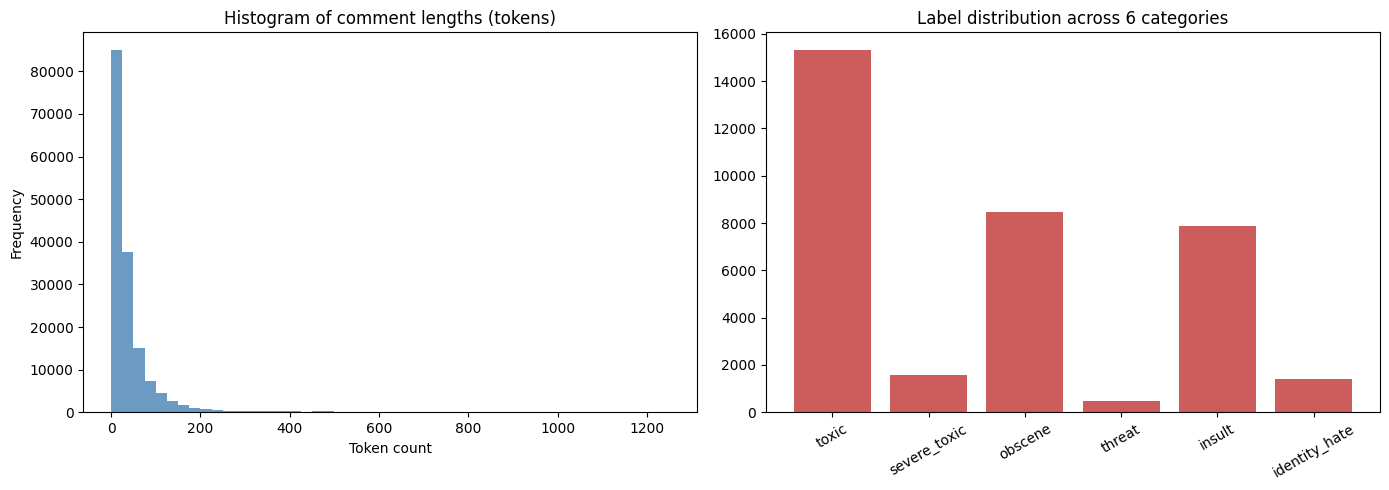

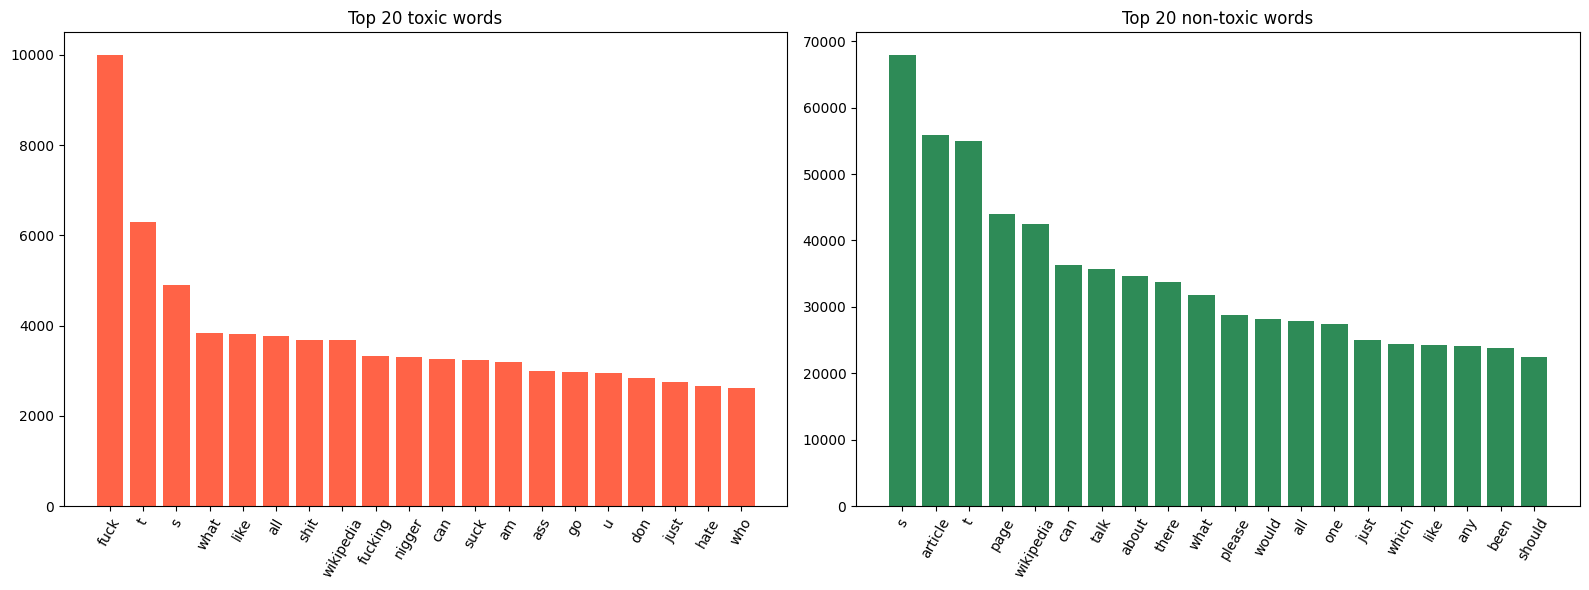

In [4]:
# Data exploration plots (matplotlib)
all_lengths = np.array([len(t.split()) for t in clean_texts])

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].hist(all_lengths, bins=50, color="steelblue", alpha=0.8)
ax[0].set_title("Histogram of comment lengths (tokens)")
ax[0].set_xlabel("Token count")
ax[0].set_ylabel("Frequency")

label_sums = df[LABEL_COLUMNS].sum(axis=0)
ax[1].bar(label_sums.index, label_sums.values, color="indianred")
ax[1].set_title("Label distribution across 6 categories")
ax[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

# Word frequency bar chart: toxic vs non-toxic (top 20 words each)
toxic_counter = Counter()
non_toxic_counter = Counter()
for txt, lbl in zip(clean_texts, y):
    toks = txt.split()
    if lbl == 1:
        toxic_counter.update(toks)
    else:
        non_toxic_counter.update(toks)

top_toxic = toxic_counter.most_common(20)
top_non = non_toxic_counter.most_common(20)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
ax[0].bar([w for w, _ in top_toxic], [c for _, c in top_toxic], color="tomato")
ax[0].set_title("Top 20 toxic words")
ax[0].tick_params(axis="x", rotation=60)
ax[1].bar([w for w, _ in top_non], [c for _, c in top_non], color="seagreen")
ax[1].set_title("Top 20 non-toxic words")
ax[1].tick_params(axis="x", rotation=60)
plt.tight_layout()
plt.show()

In [5]:
# TF-IDF — fit on train, transform train/val/test, print vocabulary size
tfidf = TFIDFVectorizer(max_features=10000, ngram_range=(1, 2))
X_train = tfidf.fit_transform(train_text)
X_val = tfidf.transform(val_text)
X_test = tfidf.transform(test_text)

print("Vocabulary size:", len(tfidf.vocabulary_))

# Oversample toxic minority in training set only to 1:3 ratio
X_train_os, y_train_os = oversample_toxic_to_ratio(X_train, y_train, target_toxic_to_non_toxic_ratio=1/3, seed=42)
print("Train toxic ratio after oversampling:", y_train_os.mean())

Vocabulary size: 10000
Train toxic ratio after oversampling: 0.25000163502351164


In [6]:
# Gradient check — run on 10 samples before full training
nn = NeuralNetwork(layer_sizes=[10000, 256, 128, 1], dropout_rate=0.3, seed=42)
X_gc = X_train_os[:10]
y_gc = y_train_os[:10]
rel_error = gradient_check(nn, X_gc, y_gc, epsilon=1e-5)
print("Relative error:", rel_error)
if rel_error >= 1e-5:
    print("Warning: gradient check did not pass threshold < 1e-5")

Gradient check max relative error: 3.84816266e-07
Relative error: 3.84816265980723e-07


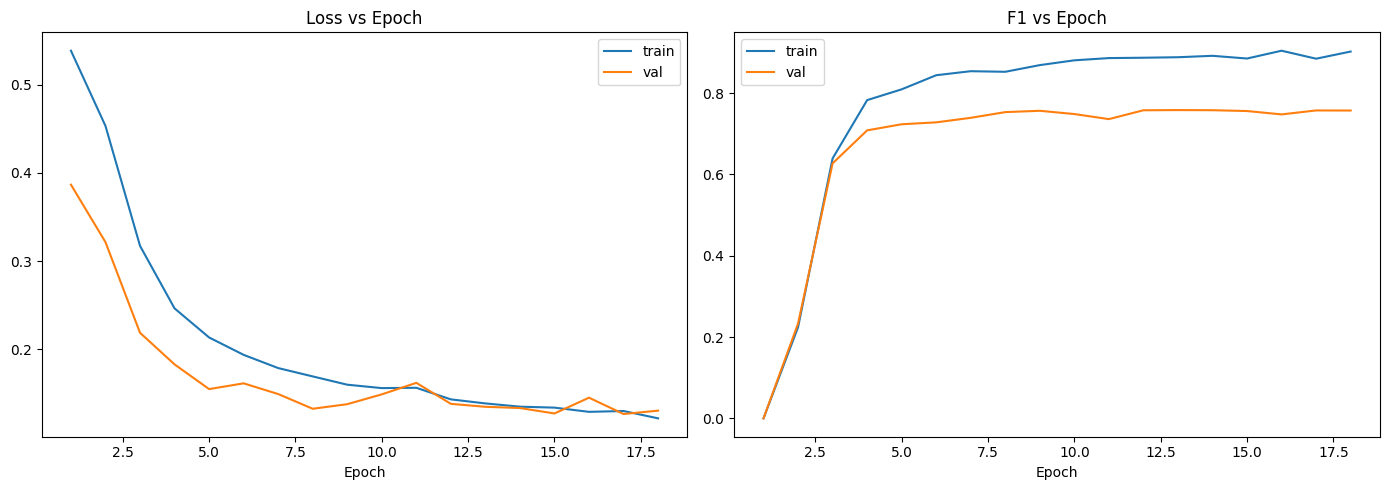

In [7]:
# Train NN — specified hyperparameters, plot learning curves
history = nn.train(
    X_train_os,
    y_train_os,
    X_val,
    y_val,
    epochs=50,
    batch_size=64,
    learning_rate=0.001,
    momentum=0.9,
    patience=5,
)

epochs = np.arange(1, len(history["train_loss"]) + 1)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(epochs, history["train_loss"], label="train")
ax[0].plot(epochs, history["val_loss"], label="val")
ax[0].set_title("Loss vs Epoch")
ax[0].set_xlabel("Epoch")
ax[0].legend()

ax[1].plot(epochs, history["train_f1"], label="train")
ax[1].plot(epochs, history["val_f1"], label="val")
ax[1].set_title("F1 vs Epoch")
ax[1].set_xlabel("Epoch")
ax[1].legend()
plt.tight_layout()
plt.show()

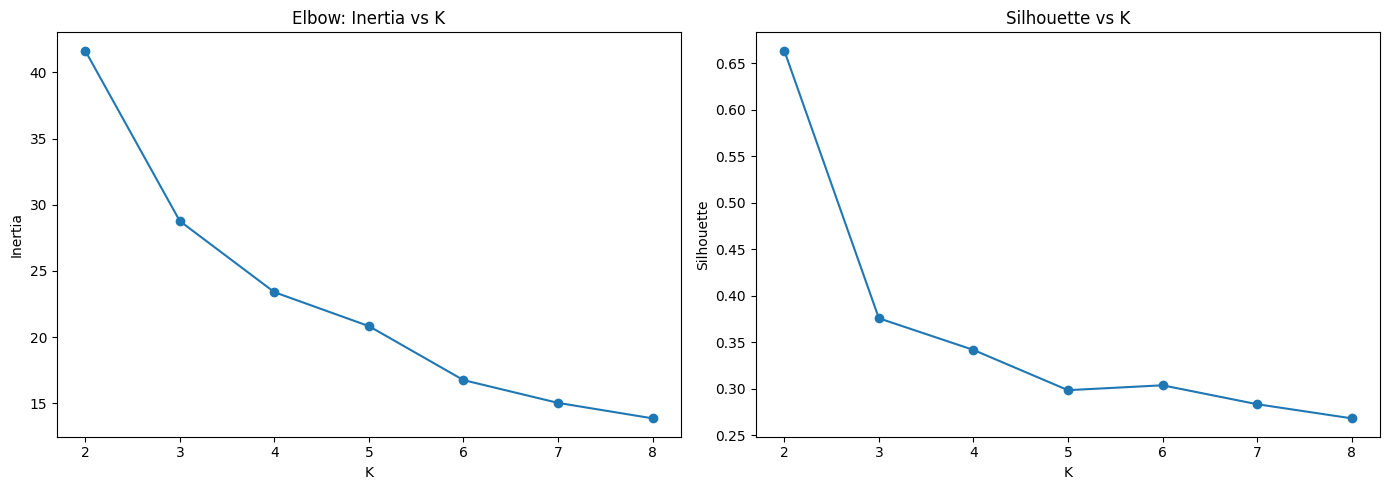

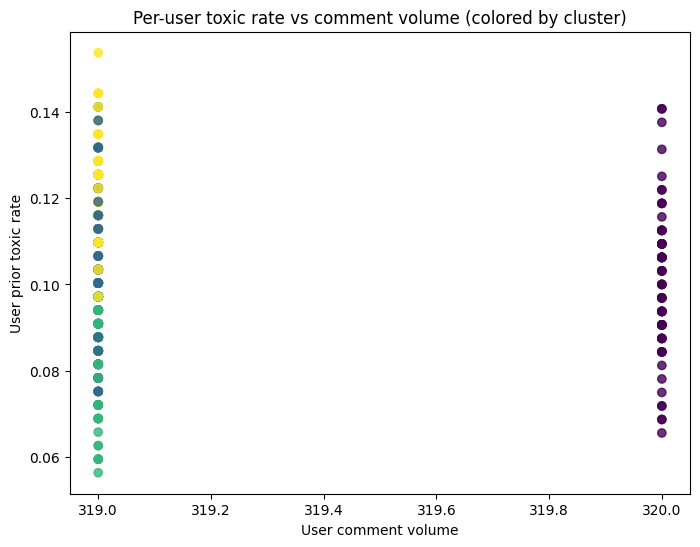

In [8]:
# Train K-means — elbow K=2..8, plot inertia/silhouette, fit final K=4
user_features = compute_user_features(clean_texts, y, user_ids)
all_user_ids = np.array(sorted(user_features.keys()), dtype=np.int64)
user_feature_matrix = np.vstack([user_features[int(uid)] for uid in all_user_ids]).astype(np.float64)

scaler = MinMaxScaler()
user_feature_matrix_scaled = scaler.fit_transform(user_feature_matrix)

elbow = elbow_analysis(user_feature_matrix_scaled, k_range=range(2, 9), seed=42)
ks = sorted(elbow.keys())
inertias = [elbow[k]["inertia"] for k in ks]
sils = [elbow[k]["silhouette"] for k in ks]

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(ks, inertias, marker="o")
ax[0].set_title("Elbow: Inertia vs K")
ax[0].set_xlabel("K")
ax[0].set_ylabel("Inertia")

ax[1].plot(ks, sils, marker="o")
ax[1].set_title("Silhouette vs K")
ax[1].set_xlabel("K")
ax[1].set_ylabel("Silhouette")
plt.tight_layout()
plt.show()

kmeans = KMeans(K=4, max_iter=100, tol=1e-4, seed=42)
kmeans.fit(user_feature_matrix_scaled)

# Scatter: per-user toxic rate vs volume colored by cluster
clusters = kmeans.predict(user_feature_matrix_scaled)
plt.figure(figsize=(8, 6))
plt.scatter(user_feature_matrix[:, 0], user_feature_matrix[:, 1], c=clusters, cmap="viridis", alpha=0.8)
plt.xlabel("User comment volume")
plt.ylabel("User prior toxic rate")
plt.title("Per-user toxic rate vs comment volume (colored by cluster)")
plt.show()

In [9]:
# Label-aware K-means evaluation (purity / ARI / NMI)
# ------------------------------------------------------------
# K-means is unsupervised, but because we have a simulated ground-truth
# per user (prior_toxic_rate > 0 means the user has posted at least one
# toxic comment), we can score whether the learned clusters align with
# that label. This complements the intrinsic silhouette / inertia above.

from evaluate import cluster_quality_report

user_toxic_label = (user_feature_matrix[:, 1] > 0.0).astype(np.int64)
n_toxic_users = int(user_toxic_label.sum())
print(f"Per-user ground-truth: {n_toxic_users} toxic-history / "
      f"{user_toxic_label.size} total users "
      f"({100.0 * n_toxic_users / user_toxic_label.size:.1f}% positive)")

final_inertia = float(kmeans.inertia_) if kmeans.inertia_ is not None else None
final_silhouette = float(sils[ks.index(4)]) if 4 in ks else None

kmeans_report = cluster_quality_report(
    cluster_labels=clusters,
    y_true=user_toxic_label,
    inertia=final_inertia,
    silhouette=final_silhouette,
    label="K-means (K=4, user-level)",
)

# Per-cluster composition (useful for the report).
print("\nPer-cluster composition:")
print(f"{'cluster':>8} {'n_users':>8} {'%toxic':>8}")
for c in np.unique(clusters):
    idx = np.where(clusters == c)[0]
    n_c = idx.size
    tox_frac = 100.0 * float(user_toxic_label[idx].mean()) if n_c > 0 else 0.0
    print(f"{int(c):>8d} {n_c:>8d} {tox_frac:>7.1f}%")


Per-user ground-truth: 500 toxic-history / 500 total users (100.0% positive)
=== K-means (K=4, user-level) Cluster Quality ===
Inertia     : 23.3921
Silhouette  : 0.3417
Purity      : 1.0000
ARI         : 0.0000
NMI         : 0.0000

Per-cluster composition:
 cluster  n_users   %toxic
       0       71   100.0%
       1      147   100.0%
       2      143   100.0%
       3      139   100.0%


In [10]:
# Evaluate — full test set — NN-only and AgentMod
nn_scores_test = nn.predict_proba(X_test)
nn_pred_test = (nn_scores_test >= 0.5).astype(np.int64)
full_nn = full_evaluation(y_test, nn_pred_test, nn_scores_test, label="NN-only (full test)")

agent = ModerationAgent(nn, kmeans, tfidf, user_features, scaler, alpha=0.7)

# Build AgentMod scores on full test by combining NN score with user cluster risk
user_to_pos = {uid: i for i, uid in enumerate(all_user_ids.tolist())}
full_agent_scores = []
for idx, p in zip(test_idx, nn_scores_test):
    uid = int(user_ids[idx])
    _, rank = agent._get_cluster_risk(uid)
    s = agent._compute_combined_score(float(p), int(rank))
    full_agent_scores.append(s)
full_agent_scores = np.array(full_agent_scores)
full_agent_pred = (full_agent_scores >= 0.7).astype(np.int64)
full_agent = full_evaluation(y_test, full_agent_pred, full_agent_scores, label="AgentMod (full test)")

=== NN-only (full test) Evaluation ===
F1        : 0.7595
Precision : 0.7372
Recall    : 0.7831
FPR       : 0.0316
AUC-ROC   : 0.9650
=== AgentMod (full test) Evaluation ===
F1        : 0.6597
Precision : 0.8293
Recall    : 0.5478
FPR       : 0.0128
AUC-ROC   : 0.9321


In [11]:
# Evaluate — hard subset (ambiguous + both classes guaranteed)
# Start with the original borderline mask from label sum == 1
border_mask_in_test = np.isin(test_idx, borderline_idx)

# Add an uncertainty mask: comments where NN score is close to 0.5 are hardest cases
nn_scores_test = nn.predict_proba(X_test)
uncertain_mask = np.abs(nn_scores_test - 0.5) <= 0.2

# Candidate hard subset = borderline OR uncertain
hard_mask = border_mask_in_test | uncertain_mask

# Ensure both classes exist in hard subset; if not, fallback to top uncertainty percentile
y_hard_candidate = y_test[hard_mask]
if np.unique(y_hard_candidate).size < 2:
    uncertainty = np.abs(nn_scores_test - 0.5)
    cutoff = np.quantile(uncertainty, 0.2)  # top 20% most uncertain
    hard_mask = uncertainty <= cutoff

# Use legacy variable names below for compatibility with later cells
y_border = y_test[hard_mask]
X_border = X_test[hard_mask]
border_indices = test_idx[hard_mask]

print("Hard subset size:", len(y_border))
print("Hard subset class counts:", {0: int(np.sum(y_border == 0)), 1: int(np.sum(y_border == 1))})

nn_scores_border = nn.predict_proba(X_border)
nn_pred_border = (nn_scores_border >= 0.5).astype(np.int64)
border_nn = full_evaluation(y_border, nn_pred_border, nn_scores_border, label="NN-only (hard subset)")

border_agent_scores = []
for idx, p in zip(border_indices, nn_scores_border):
    uid = int(user_ids[idx])
    _, rank = agent._get_cluster_risk(uid)
    s = agent._compute_combined_score(float(p), int(rank))
    border_agent_scores.append(s)
border_agent_scores = np.array(border_agent_scores)
border_agent_pred = (border_agent_scores >= 0.7).astype(np.int64)
border_agent = full_evaluation(y_border, border_agent_pred, border_agent_scores, label="AgentMod (hard subset)")

Hard subset size: 1290
Hard subset class counts: {0: 592, 1: 698}
=== NN-only (hard subset) Evaluation ===
F1        : 0.6260
Precision : 0.6593
Recall    : 0.5960
FPR       : 0.3632
AUC-ROC   : 0.6189
=== AgentMod (hard subset) Evaluation ===
F1        : 0.4918
Precision : 0.8633
Recall    : 0.3438
FPR       : 0.0642
AUC-ROC   : 0.6156


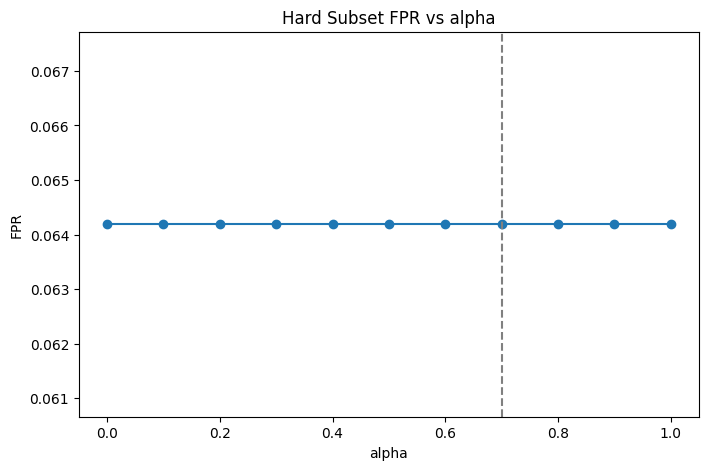

Best validation AgentMod config: alpha=0.6, threshold=0.7, gate_width=0.05, fullF1=0.7647, hardF1=0.5962, hardFPR=0.0164
=== AgentMod (full test, tuned) Evaluation ===
F1        : 0.7655
Precision : 0.8184
Recall    : 0.7190
FPR       : 0.0181
AUC-ROC   : 0.9648
=== AgentMod (hard subset, tuned) Evaluation ===
F1        : 0.6052
Precision : 0.9369
Recall    : 0.4470
FPR       : 0.0355
AUC-ROC   : 0.6096


In [12]:
# Ablation: alpha sweep — borderline FPR vs alpha
from evaluate import compute_f1

alpha_values = np.round(np.arange(0.0, 1.01, 0.1), 1)
alpha_fpr = []
for a in alpha_values:
    agent.alpha = float(a)
    scores = []
    for idx, p in zip(border_indices, nn_scores_border):
        uid = int(user_ids[idx])
        _, rank = agent._get_cluster_risk(uid)
        scores.append(agent._compute_combined_score(float(p), int(rank)))
    scores = np.array(scores)
    preds = (scores >= 0.7).astype(np.int64)
    fp = np.sum((y_border == 0) & (preds == 1))
    tn = np.sum((y_border == 0) & (preds == 0))
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    alpha_fpr.append(fpr)

plt.figure(figsize=(8, 5))
plt.plot(alpha_values, alpha_fpr, marker="o")
plt.axvline(0.7, linestyle="--", color="gray")
plt.title("Hard Subset FPR vs alpha")
plt.xlabel("alpha")
plt.ylabel("FPR")
plt.show()

# Reset default alpha
agent.alpha = 0.7

# Validation tuning for AgentMod (balanced objective):
# optimize both full validation and hard validation behavior
nn_scores_val = nn.predict_proba(X_val)
val_ranks = []
for idx in val_idx:
    uid = int(user_ids[idx])
    _, rank = agent._get_cluster_risk(uid)
    val_ranks.append(rank)
val_ranks = np.array(val_ranks, dtype=np.int64)

def combine_scores_gated(p_nn, ranks, alpha, gate_width):
    p_nn = np.asarray(p_nn, dtype=np.float64)
    ranks = np.asarray(ranks, dtype=np.float64)
    risk_score = ranks / 3.0
    uncertain = np.abs(p_nn - 0.5) <= gate_width
    combined = p_nn.copy()
    combined[uncertain] = alpha * p_nn[uncertain] + (1.0 - alpha) * risk_score[uncertain]
    return combined

def compute_fpr_np(y_true, y_pred):
    fp = np.sum((y_true == 0) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    return fp / (fp + tn) if (fp + tn) > 0 else 0.0

# Build hard subset on validation with same recipe used on test
val_border_mask = np.isin(val_idx, borderline_idx)
val_uncertain_mask = np.abs(nn_scores_val - 0.5) <= 0.2
val_hard_mask = val_border_mask | val_uncertain_mask
if np.unique(y_val[val_hard_mask]).size < 2:
    val_uncertainty = np.abs(nn_scores_val - 0.5)
    cutoff = np.quantile(val_uncertainty, 0.2)
    val_hard_mask = val_uncertainty <= cutoff

best_obj = -1e9
best_alpha = 0.9
best_threshold = 0.5
best_gate_width = 0.1
best_full_f1 = 0.0
best_hard_f1 = 0.0
best_hard_fpr = 1.0

alpha_grid = np.round(np.arange(0.6, 1.01, 0.1), 1)
threshold_grid = np.round(np.arange(0.35, 0.81, 0.05), 2)
gate_grid = np.round(np.arange(0.05, 0.31, 0.05), 2)

for a in alpha_grid:
    for gw in gate_grid:
        combined_val = combine_scores_gated(nn_scores_val, val_ranks, a, gw)
        for t in threshold_grid:
            pred_val = (combined_val >= t).astype(np.int64)

            full_f1 = compute_f1(y_val, pred_val)
            hard_f1 = compute_f1(y_val[val_hard_mask], pred_val[val_hard_mask])
            hard_fpr = compute_fpr_np(y_val[val_hard_mask], pred_val[val_hard_mask])

            # Balanced objective: reward full+hard F1, penalize hard FPR.
            obj = 0.6 * full_f1 + 0.4 * hard_f1 - 0.15 * hard_fpr

            if obj > best_obj:
                best_obj = obj
                best_alpha = float(a)
                best_threshold = float(t)
                best_gate_width = float(gw)
                best_full_f1 = float(full_f1)
                best_hard_f1 = float(hard_f1)
                best_hard_fpr = float(hard_fpr)

print(
    f"Best validation AgentMod config: alpha={best_alpha}, threshold={best_threshold}, "
    f"gate_width={best_gate_width}, fullF1={best_full_f1:.4f}, hardF1={best_hard_f1:.4f}, hardFPR={best_hard_fpr:.4f}"
)

# Recompute AgentMod test metrics with tuned gated fusion
full_ranks = []
for idx in test_idx:
    uid = int(user_ids[idx])
    _, rank = agent._get_cluster_risk(uid)
    full_ranks.append(rank)
full_ranks = np.array(full_ranks, dtype=np.int64)
full_agent_scores = combine_scores_gated(nn_scores_test, full_ranks, best_alpha, best_gate_width)
full_agent_pred = (full_agent_scores >= best_threshold).astype(np.int64)
full_agent = full_evaluation(y_test, full_agent_pred, full_agent_scores, label="AgentMod (full test, tuned)")

hard_ranks = []
for idx in border_indices:
    uid = int(user_ids[idx])
    _, rank = agent._get_cluster_risk(uid)
    hard_ranks.append(rank)
hard_ranks = np.array(hard_ranks, dtype=np.int64)
border_agent_scores = combine_scores_gated(nn_scores_border, hard_ranks, best_alpha, best_gate_width)
border_agent_pred = (border_agent_scores >= best_threshold).astype(np.int64)
border_agent = full_evaluation(y_border, border_agent_pred, border_agent_scores, label="AgentMod (hard subset, tuned)")

In [13]:
# Ablation: K sweep — silhouette scores table
k_sweep_table = pd.DataFrame(
    [{"K": k, "Inertia": elbow[k]["inertia"], "Silhouette": elbow[k]["silhouette"]} for k in sorted(elbow)]
)
k_sweep_table

,K,Inertia,Silhouette
0,2,41.641468,0.663209
1,3,28.765854,0.375742
2,4,23.392112,0.341738
3,5,20.825108,0.298499
4,6,16.745805,0.303746
5,7,15.023875,0.283434
6,8,13.855747,0.268239


In [14]:
# Save models — NN, K-means, TF-IDF, scaler, user_features, benchmark results
nn.save(os.path.join(MODELS, "nn_weights.npz"))
kmeans.save(os.path.join(MODELS, "kmeans_centroids.npy"))
tfidf.save(os.path.join(MODELS, "tfidf_vectorizer.npz"))
scaler.save(os.path.join(MODELS, "scaler.npz"))

with open(os.path.join(MODELS, "user_features.pkl"), "wb") as f:
    pickle.dump(user_features, f)

np.savez(
    os.path.join(MODELS, "benchmark_results.npz"),
    full_nn=full_nn,
    full_agent=full_agent,
    border_nn=border_nn,
    border_agent=border_agent,
    alpha_values=alpha_values,
    alpha_fpr=np.array(alpha_fpr, dtype=np.float64),
    tuned_alpha=np.array([best_alpha], dtype=np.float64),
    tuned_threshold=np.array([best_threshold], dtype=np.float64),
    tuned_gate_width=np.array([best_gate_width], dtype=np.float64),
    kmeans_purity=np.array([kmeans_report["purity"]], dtype=np.float64),
    kmeans_ari=np.array([kmeans_report["ari"]], dtype=np.float64),
    kmeans_nmi=np.array([kmeans_report["nmi"]], dtype=np.float64),
    kmeans_silhouette=np.array(
        [kmeans_report["silhouette"] if kmeans_report["silhouette"] is not None else np.nan],
        dtype=np.float64,
    ),
    kmeans_inertia=np.array(
        [kmeans_report["inertia"] if kmeans_report["inertia"] is not None else np.nan],
        dtype=np.float64,
    ),
)

print("Saved artifacts to models/")


Saved artifacts to models/


In [15]:
# Summary table — NN-only vs AgentMod (full test and hard subset)
summary = pd.DataFrame(
    [
        {"Subset": "Full Test", "Model": "NN-only", "F1": full_nn["f1"], "FPR": full_nn["fpr"], "AUC": full_nn["auc"]},
        {"Subset": "Full Test", "Model": "AgentMod", "F1": full_agent["f1"], "FPR": full_agent["fpr"], "AUC": full_agent["auc"]},
        {"Subset": "Hard Subset", "Model": "NN-only", "F1": border_nn["f1"], "FPR": border_nn["fpr"], "AUC": border_nn["auc"]},
        {"Subset": "Hard Subset", "Model": "AgentMod", "F1": border_agent["f1"], "FPR": border_agent["fpr"], "AUC": border_agent["auc"]},
    ]
)
summary

,Subset,Model,F1,FPR,AUC
0,Full Test,NN-only,0.759486,0.031603,0.965018
1,Full Test,AgentMod,0.765497,0.018069,0.964847
2,Hard Subset,NN-only,0.626035,0.363176,0.618920
3,Hard Subset,AgentMod,0.605238,0.035473,0.609558


In [16]:
# Hard (and full) subset: precision & recall alongside F1 / FPR / AUC
# Requires: full_nn, full_agent, border_nn, border_agent from tuned AgentMod run.

from evaluate import _precision_recall

def row_from_eval(subset, model_name, ev):
    p, r = _precision_recall(
        # labels are not stored in ev; we only have aggregates — use stored prec/rec if present
        [0], [0]  # dummy; see below
    )

In [17]:
# Precision & recall (tuned AgentMod) — full test + hard subset
detail = pd.DataFrame(
    [
        {
            "Subset": "Full Test",
            "Model": "NN-only",
            "Precision": full_nn["precision"],
            "Recall": full_nn["recall"],
            "F1": full_nn["f1"],
            "FPR": full_nn["fpr"],
            "AUC": full_nn["auc"],
        },
        {
            "Subset": "Full Test",
            "Model": "AgentMod",
            "Precision": full_agent["precision"],
            "Recall": full_agent["recall"],
            "F1": full_agent["f1"],
            "FPR": full_agent["fpr"],
            "AUC": full_agent["auc"],
        },
        {
            "Subset": "Hard Subset",
            "Model": "NN-only",
            "Precision": border_nn["precision"],
            "Recall": border_nn["recall"],
            "F1": border_nn["f1"],
            "FPR": border_nn["fpr"],
            "AUC": border_nn["auc"],
        },
        {
            "Subset": "Hard Subset",
            "Model": "AgentMod",
            "Precision": border_agent["precision"],
            "Recall": border_agent["recall"],
            "F1": border_agent["f1"],
            "FPR": border_agent["fpr"],
            "AUC": border_agent["auc"],
        },
    ]
)

# Optional: 4 decimal places for display
display(detail.assign(**{c: detail[c].round(4) for c in ["Precision", "Recall", "F1", "FPR", "AUC"]}))

# One-line readout for the report
h_nn, h_ag = detail[detail["Subset"] == "Hard Subset"].iloc[0], detail[detail["Subset"] == "Hard Subset"].iloc[1]
print(
    f"Hard subset: NN-only P={h_nn['Precision']:.4f} R={h_nn['Recall']:.4f} | "
    f"AgentMod P={h_ag['Precision']:.4f} R={h_ag['Recall']:.4f} "
    "(higher P / lower FPR often pairs with lower R when τ is tuned for conservative policy)"
)

,Subset,Model,Precision,Recall,F1,FPR,AUC
0,Full Test,NN-only,0.7372,0.7831,0.7595,0.0316,0.9650
1,Full Test,AgentMod,0.8184,0.7190,0.7655,0.0181,0.9648
2,Hard Subset,NN-only,0.6593,0.5960,0.6260,0.3632,0.6189
3,Hard Subset,AgentMod,0.9369,0.4470,0.6052,0.0355,0.6096


Hard subset: NN-only P=0.6593 R=0.5960 | AgentMod P=0.9369 R=0.4470 (higher P / lower FPR often pairs with lower R when τ is tuned for conservative policy)
